In [1]:
"""
ApexPlanet Data Analytics Internship - Task 3
Deep-Dive Analysis: Cohort Analysis (Customer Retention & Lifetime Value)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
sns.set_style("whitegrid")
df = pd.read_excel('cleaned_dataset.xls')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

OUT = './charts'
os.makedirs(OUT, exist_ok=True)
COLORS = ['#2E75B6', '#F4B942', '#70AD47', '#C0504D', '#8064A2']

In [3]:
# ─────────────────────────────────────────────
# STEP 1: Build Cohorts (by first purchase month)
# ─────────────────────────────────────────────
df['Order_Month_Period'] = df['Order_Date'].dt.to_period('M')

# Each customer's cohort = month of their FIRST ever order
first_purchase = df.groupby('Customer_ID')['Order_Month_Period'].min().reset_index()
first_purchase.columns = ['Customer_ID', 'Cohort_Month']
df = df.merge(first_purchase, on='Customer_ID')

# Cohort Index = how many months after first purchase did this order happen
def month_diff(later, earlier):
    return (later.year - earlier.year) * 12 + (later.month - earlier.month)

df['Cohort_Index'] = df.apply(
    lambda r: month_diff(r['Order_Month_Period'], r['Cohort_Month']), axis=1
)

print("=" * 60)
print("COHORT SETUP")
print("=" * 60)
print(f"Unique customers: {df['Customer_ID'].nunique()}")
print(f"Cohort months identified: {df['Cohort_Month'].nunique()}")
print(f"\nCustomers per cohort month:")
print(first_purchase['Cohort_Month'].value_counts().sort_index())


COHORT SETUP
Unique customers: 947
Cohort months identified: 13

Customers per cohort month:
Cohort_Month
2025-01    76
2025-02    85
2025-03    89
2025-04    77
2025-05    83
2025-06    79
2025-07    80
2025-08    70
2025-09    72
2025-10    76
2025-11    71
2025-12    86
2026-01     3
Freq: M, Name: count, dtype: int64


In [4]:
# ─────────────────────────────────────────────
# STEP 2: Retention Matrix (customer count)
# ─────────────────────────────────────────────
cohort_counts = df.groupby(['Cohort_Month', 'Cohort_Index'])['Customer_ID']\
                   .nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='Cohort_Month', columns='Cohort_Index', values='Customer_ID')

cohort_sizes = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

print("\n" + "=" * 60)
print("RETENTION MATRIX (% of cohort still active)")
print("=" * 60)
print(retention_matrix.round(1))


RETENTION MATRIX (% of cohort still active)
Cohort_Index     0    1    2    3    4    5    6    7    8    9    10   11
Cohort_Month                                                              
2025-01       100.0  1.3  NaN  1.3  1.3  2.6  NaN  NaN  1.3  1.3  2.6  2.6
2025-02       100.0  NaN  1.2  NaN  NaN  1.2  1.2  1.2  NaN  1.2  NaN  NaN
2025-03       100.0  1.1  1.1  NaN  NaN  1.1  1.1  2.2  NaN  4.5  NaN  NaN
2025-04       100.0  NaN  1.3  NaN  NaN  2.6  NaN  NaN  1.3  NaN  NaN  NaN
2025-05       100.0  1.2  1.2  2.4  NaN  2.4  NaN  1.2  NaN  NaN  NaN  NaN
2025-06       100.0  NaN  1.3  NaN  2.5  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2025-07       100.0  NaN  2.5  1.2  1.2  1.2  NaN  NaN  NaN  NaN  NaN  NaN
2025-08       100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2025-09       100.0  NaN  NaN  1.4  1.4  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2025-10       100.0  2.6  1.3  1.3  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2025-11       100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN 

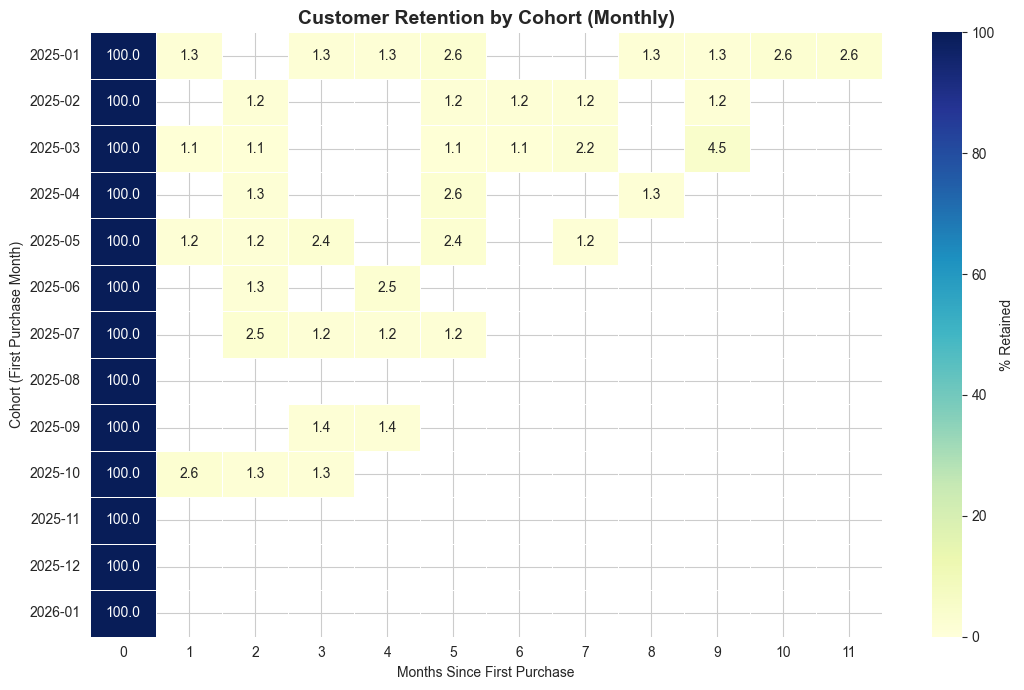

In [5]:
# ─────────────────────────────────────────────
# CHART 1: Retention Heatmap
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% Retained'},
            vmin=0, vmax=100)
ax.set_title('Customer Retention by Cohort (Monthly)', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cohort (First Purchase Month)')
plt.tight_layout()
plt.savefig(f'{OUT}/cohort_01_retention_heatmap.png', dpi=150)
plt.show()

In [6]:
# ─────────────────────────────────────────────
# STEP 3: Customer Lifetime Value (LTV) by Cohort
# ─────────────────────────────────────────────
ltv_by_cohort = df.groupby(['Cohort_Month', 'Cohort_Index'])['Total_Sales'].sum().reset_index()
ltv_pivot = ltv_by_cohort.pivot(index='Cohort_Month', columns='Cohort_Index', values='Total_Sales')
ltv_cumulative = ltv_pivot.cumsum(axis=1)

print("\n" + "=" * 60)
print("CUMULATIVE REVENUE BY COHORT (₹)")
print("=" * 60)
print(ltv_cumulative.round(0))


CUMULATIVE REVENUE BY COHORT (₹)
Cohort_Index          0           1           2           3           4   \
Cohort_Month                                                               
2025-01       10096191.0  10371491.0         NaN  10636722.0  10671326.0   
2025-02       11235881.0         NaN  11411217.0         NaN         NaN   
2025-03       13059900.0  13473792.0  13908612.0         NaN         NaN   
2025-04       11368242.0         NaN  11746736.0         NaN         NaN   
2025-05       10515264.0  10872272.0  11310353.0  11437961.0         NaN   
2025-06       12093832.0         NaN  12175452.0         NaN  12498365.0   
2025-07       11140351.0         NaN  11371917.0  11536976.0  11672832.0   
2025-08        8679639.0         NaN         NaN         NaN         NaN   
2025-09        8780776.0         NaN         NaN   9163753.0   9510912.0   
2025-10       11526375.0  11771239.0  11875425.0  11911287.0         NaN   
2025-11       11821694.0         NaN         NaN      

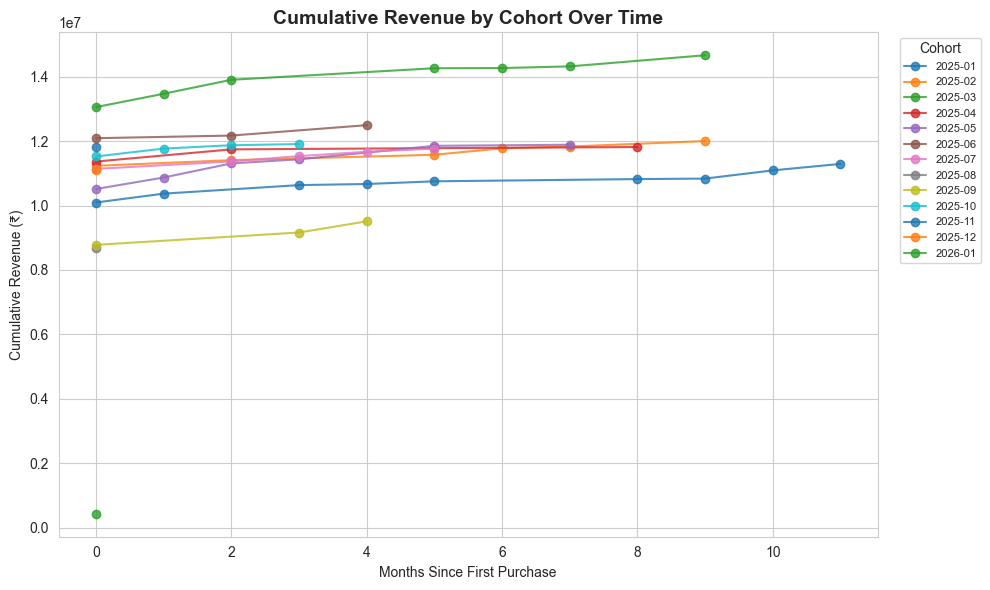

In [7]:
# ─────────────────────────────────────────────
# CHART 2: Cumulative LTV curves by cohort
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
for cohort in ltv_cumulative.index:
    row = ltv_cumulative.loc[cohort].dropna()
    ax.plot(row.index, row.values, marker='o', label=str(cohort), alpha=0.8)
ax.set_title('Cumulative Revenue by Cohort Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Cumulative Revenue (₹)')
ax.legend(title='Cohort', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUT}/cohort_02_cumulative_ltv.png', dpi=150)
plt.show()


In [8]:
# ─────────────────────────────────────────────
# STEP 4: One-time vs Repeat Customer Value Comparison
# ─────────────────────────────────────────────
cust_summary = df.groupby('Customer_ID').agg(
    Orders=('Order_ID', 'count'),
    Total_Spend=('Total_Sales', 'sum'),
    First_Purchase=('Order_Date', 'min'),
    Last_Purchase=('Order_Date', 'max')
).reset_index()
cust_summary['Customer_Type'] = np.where(cust_summary['Orders'] > 1, 'Repeat', 'One-Time')

print("\n" + "=" * 60)
print("ONE-TIME vs REPEAT CUSTOMERS")
print("=" * 60)
summary_stats = cust_summary.groupby('Customer_Type').agg(
    Customer_Count=('Customer_ID', 'count'),
    Avg_Spend=('Total_Spend', 'mean'),
    Total_Revenue=('Total_Spend', 'sum')
)
summary_stats['Pct_of_Customers'] = (summary_stats['Customer_Count'] / summary_stats['Customer_Count'].sum() * 100).round(1)
summary_stats['Pct_of_Revenue'] = (summary_stats['Total_Revenue'] / summary_stats['Total_Revenue'].sum() * 100).round(1)
print(summary_stats.round(2))


ONE-TIME vs REPEAT CUSTOMERS
               Customer_Count  Avg_Spend  Total_Revenue  Pct_of_Customers  \
Customer_Type                                                               
One-Time                  895  137682.28   1.232256e+08              94.5   
Repeat                     52  311034.64   1.617380e+07               5.5   

               Pct_of_Revenue  
Customer_Type                  
One-Time                 88.4  
Repeat                   11.6  


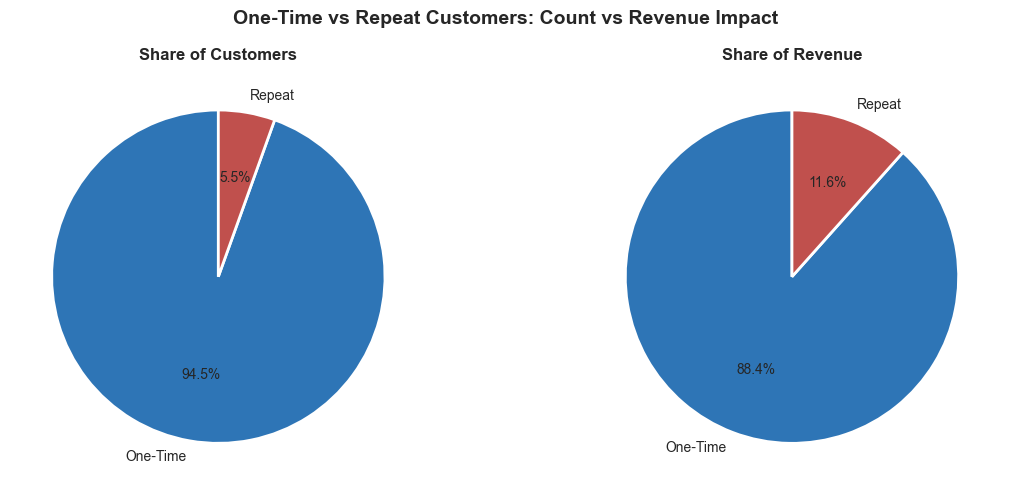

In [9]:
# ─────────────────────────────────────────────
# CHART 3: One-Time vs Repeat — Revenue Contribution
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(summary_stats['Customer_Count'], labels=summary_stats.index, autopct='%1.1f%%',
            colors=[COLORS[0], COLORS[3]], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Share of Customers', fontsize=12, fontweight='bold')

axes[1].pie(summary_stats['Total_Revenue'], labels=summary_stats.index, autopct='%1.1f%%',
            colors=[COLORS[0], COLORS[3]], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Share of Revenue', fontsize=12, fontweight='bold')

fig.suptitle('One-Time vs Repeat Customers: Count vs Revenue Impact', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT}/cohort_03_onetime_vs_repeat.png', dpi=150)
plt.show()

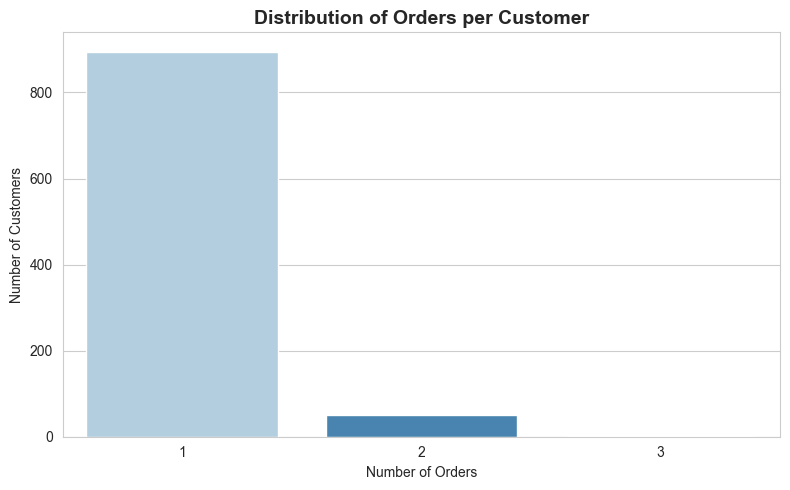

In [10]:
# ─────────────────────────────────────────────
# CHART 4: Distribution of orders-per-customer
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
order_counts = cust_summary['Orders'].value_counts().sort_index()
sns.barplot(x=order_counts.index, y=order_counts.values, hue=order_counts.index,
            palette='Blues_d', ax=ax, legend=False)
ax.set_title('Distribution of Orders per Customer', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Orders'); ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(f'{OUT}/cohort_04_orders_per_customer.png', dpi=150)
plt.show()

In [11]:
# ─────────────────────────────────────────────
# STEP 5: Top repeat customers by LTV
# ─────────────────────────────────────────────
top_repeat = cust_summary[cust_summary['Customer_Type'] == 'Repeat']\
    .sort_values('Total_Spend', ascending=False).head(10)
print("\n" + "=" * 60)
print("TOP 10 REPEAT CUSTOMERS BY LIFETIME VALUE")
print("=" * 60)
print(top_repeat[['Customer_ID', 'Orders', 'Total_Spend']].to_string(index=False))


TOP 10 REPEAT CUSTOMERS BY LIFETIME VALUE
Customer_ID  Orders  Total_Spend
   Cust9510       2    867333.24
   Cust6845       2    769479.75
   Cust6532       2    610981.74
   Cust6082       2    548416.39
   Cust3689       2    542484.08
   Cust3730       2    538633.97
   Cust4706       2    528036.44
   Cust9693       2    511421.86
   Cust7374       2    511309.40
   Cust9089       2    469247.10


In [12]:

# ─────────────────────────────────────────────
# KEY FINDINGS SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("KEY COHORT FINDINGS")
print("=" * 60)
n_repeat = (cust_summary['Customer_Type'] == 'Repeat').sum()
n_total = len(cust_summary)
repeat_rev_pct = summary_stats.loc['Repeat', 'Pct_of_Revenue']
print(f"""
1. Repeat purchase rate is low: only {n_repeat} of {n_total} customers ({n_repeat/n_total*100:.1f}%)
   placed more than one order in the observed period.

2. Despite being a small group, repeat customers contribute {repeat_rev_pct}% of total revenue
   -- disproportionate to their {n_repeat/n_total*100:.1f}% share of the customer base.

3. Retention drops sharply after month 0 for most cohorts, consistent with a
   largely one-time-purchase customer base rather than a subscription-like repeat pattern.

NOTE: With only {n_repeat} repeat customers out of {n_total}, cohort retention curves are based
on a small sample and should be treated as directional, not statistically robust.
""")

cust_summary.to_csv('customer_ltv_summary.csv', index=False)




KEY COHORT FINDINGS

1. Repeat purchase rate is low: only 52 of 947 customers (5.5%)
   placed more than one order in the observed period.

2. Despite being a small group, repeat customers contribute 11.6% of total revenue
   -- disproportionate to their 5.5% share of the customer base.

3. Retention drops sharply after month 0 for most cohorts, consistent with a
   largely one-time-purchase customer base rather than a subscription-like repeat pattern.

NOTE: With only 52 repeat customers out of 947, cohort retention curves are based
on a small sample and should be treated as directional, not statistically robust.

